In [1]:
import pandas as pd
import numpy as np
import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [2]:
DATA_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\data\processed\emi_prediction_dataset_cleaned.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (404800, 27)


In [3]:
expense_columns = [
    "monthly_rent",
    "school_fees",
    "college_fees",
    "travel_expenses",
    "groceries_utilities",
    "other_monthly_expenses"
]

df["total_living_expenses"] = df[expense_columns].sum(axis=1)

df["total_monthly_commitments"] = (
    df["total_living_expenses"]
    + df["current_emi_amount"]
)

df["disposable_income"] = (
    df["monthly_salary"]
    - df["total_monthly_commitments"]
)

salary_safe = df["monthly_salary"].replace(0, np.nan)

df["expense_to_income_ratio"] = (
    df["total_living_expenses"] / salary_safe
)

df["commitment_to_income_ratio"] = (
    df["total_monthly_commitments"] / salary_safe
)

df["current_emi_to_income_ratio"] = (
    df["current_emi_amount"] / salary_safe
)

df["requested_amount_to_income"] = (
    df["requested_amount"] / salary_safe
)

df["emergency_fund_to_income"] = (
    df["emergency_fund"] / salary_safe
)

print("Financial features recreated successfully!")

Financial features recreated successfully!


In [4]:
TARGET = "max_monthly_emi"

X = df.drop(
    columns=[
        "max_monthly_emi",
        "emi_eligibility"
    ]
).copy()

y = df[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget statistics:")
display(y.describe())

X shape: (404800, 33)
y shape: (404800,)

Target statistics:


count    404800.000000
mean       6763.602156
std        7741.263317
min         500.000000
25%         500.000000
50%        4211.200000
75%        9792.000000
max       91040.400000
Name: max_monthly_emi, dtype: float64

In [5]:
print("Missing target values:", y.isnull().sum())
print("Infinite target values:", np.isinf(y).sum())

print("\nMinimum EMI:", y.min())
print("Maximum EMI:", y.max())
print("Mean EMI:", y.mean())
print("Median EMI:", y.median())

Missing target values: 0
Infinite target values: 0

Minimum EMI: 500.0
Maximum EMI: 91040.4
Mean EMI: 6763.602156101779
Median EMI: 4211.2


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training X:", X_train.shape)
print("Testing X :", X_test.shape)

print("Training y:", y_train.shape)
print("Testing y :", y_test.shape)

Training X: (323840, 33)
Testing X : (80960, 33)
Training y: (323840,)
Testing y : (80960,)


In [7]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numerical features: 25
['age', 'monthly_salary', 'years_of_employment', 'monthly_rent', 'family_size', 'dependents', 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund', 'requested_amount', 'requested_tenure', 'total_living_expenses', 'total_monthly_commitments', 'disposable_income', 'expense_to_income_ratio', 'commitment_to_income_ratio', 'current_emi_to_income_ratio', 'requested_amount_to_income', 'emergency_fund_to_income']

Categorical features: 8
['gender', 'marital_status', 'education', 'employment_type', 'company_type', 'house_type', 'existing_loans', 'emi_scenario']


In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Regression preprocessing pipeline created!")

Regression preprocessing pipeline created!


In [9]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

print("Original training:", X_train.shape)
print("Processed training:", X_train_processed.shape)

print("\nOriginal testing:", X_test.shape)
print("Processed testing:", X_test_processed.shape)

Original training: (323840, 33)
Processed training: (323840, 51)

Original testing: (80960, 33)
Processed testing: (80960, 51)


In [10]:
print("NaN in training:",
      np.isnan(X_train_processed).sum())

print("NaN in testing:",
      np.isnan(X_test_processed).sum())

print("Infinity in training:",
      np.isinf(X_train_processed).sum())

print("Infinity in testing:",
      np.isinf(X_test_processed).sum())

NaN in training: 0
NaN in testing: 0
Infinity in training: 0
Infinity in testing: 0


In [11]:
REGRESSION_MODEL_PATH = Path(
    r"C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression"
)

REGRESSION_MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

regression_preprocessor_path = (
    REGRESSION_MODEL_PATH /
    "regression_preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    regression_preprocessor_path
)

print("Regression preprocessor saved!")
print("Path:", regression_preprocessor_path)

Regression preprocessor saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\regression_preprocessor.pkl


In [13]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

print("Training Linear Regression...")

linear_model.fit(
    X_train_processed,
    y_train
)



Training Linear Regression...


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred_linear = linear_model.predict(
    X_test_processed
)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_linear))

Predictions generated successfully!
Number of predictions: 80960


In [15]:
linear_mae = mean_absolute_error(
    y_test,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test,
    y_pred_linear
)

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)

print(f"MAE : ₹{linear_mae:,.2f}")
print(f"RMSE: ₹{linear_rmse:,.2f}")
print(f"R²  : {linear_r2:.4f}")

LINEAR REGRESSION RESULTS
MAE : ₹2,915.40
RMSE: ₹4,050.79
R²  : 0.7221


In [16]:
comparison = pd.DataFrame({
    "Actual_EMI": y_test.values,
    "Predicted_EMI": y_pred_linear
})

display(comparison.head(10))

,Actual_EMI,Predicted_EMI
0,5445.00,4823.682231
1,5665.00,4866.314503
2,500.00,647.156946
3,6195.20,5131.893153
4,3963.96,7791.017219
5,1134.00,-922.408574
6,16080.00,10618.302332
7,7650.00,4895.782699
8,24400.00,18767.039198
9,11814.00,10543.036296


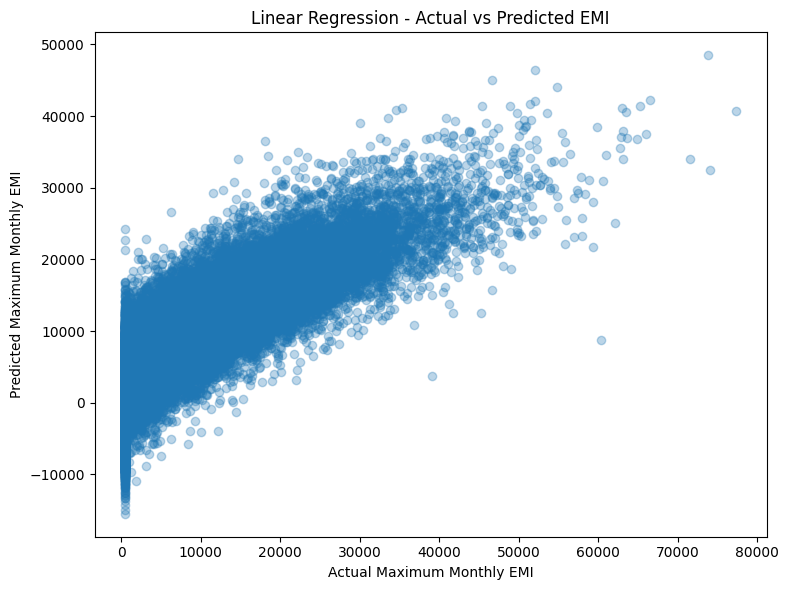

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.3
)

plt.xlabel("Actual Maximum Monthly EMI")
plt.ylabel("Predicted Maximum Monthly EMI")
plt.title("Linear Regression - Actual vs Predicted EMI")

plt.tight_layout()
plt.show()

In [18]:
linear_model_path = (
    REGRESSION_MODEL_PATH /
    "linear_regression.pkl"
)

joblib.dump(
    linear_model,
    linear_model_path
)

print("Linear Regression model saved!")
print("Path:", linear_model_path)

Linear Regression model saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\linear_regression.pkl


In [19]:
linear_model_path = (
    REGRESSION_MODEL_PATH /
    "linear_regression.pkl"
)

joblib.dump(
    linear_model,
    linear_model_path
)

print("Linear Regression model saved!")
print("Path:", linear_model_path)

Linear Regression model saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\linear_regression.pkl


In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
random_forest_regressor = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

print("Training Random Forest Regressor...")

random_forest_regressor.fit(
    X_train_processed,
    y_train
)

Training Random Forest Regressor...


,n_estimators,150
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred_rf_reg = random_forest_regressor.predict(
    X_test_processed
)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf_reg))

print("\nMinimum predicted EMI:", y_pred_rf_reg.min())
print("Maximum predicted EMI:", y_pred_rf_reg.max())

Predictions generated successfully!
Number of predictions: 80960

Minimum predicted EMI: 500.0
Maximum predicted EMI: 62244.514666666684


In [23]:
rf_reg_mae = mean_absolute_error(
    y_test,
    y_pred_rf_reg
)

rf_reg_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf_reg
    )
)

rf_reg_r2 = r2_score(
    y_test,
    y_pred_rf_reg
)

print("=" * 60)
print("RANDOM FOREST REGRESSION RESULTS")
print("=" * 60)

print(f"MAE : ₹{rf_reg_mae:,.2f}")
print(f"RMSE: ₹{rf_reg_rmse:,.2f}")
print(f"R²  : {rf_reg_r2:.4f}")

RANDOM FOREST REGRESSION RESULTS
MAE : ₹470.44
RMSE: ₹1,021.74
R²  : 0.9823


In [24]:
comparison_rf = pd.DataFrame({
    "Actual_EMI": y_test.values,
    "Predicted_EMI": y_pred_rf_reg
})

display(
    comparison_rf.head(10)
)

,Actual_EMI,Predicted_EMI
0,5445.00,5300.049333
1,5665.00,5234.330667
2,500.00,529.120000
3,6195.20,6472.276667
4,3963.96,3399.338600
5,1134.00,1099.321800
6,16080.00,16749.963333
7,7650.00,7348.913333
8,24400.00,26962.013333
9,11814.00,10604.268000


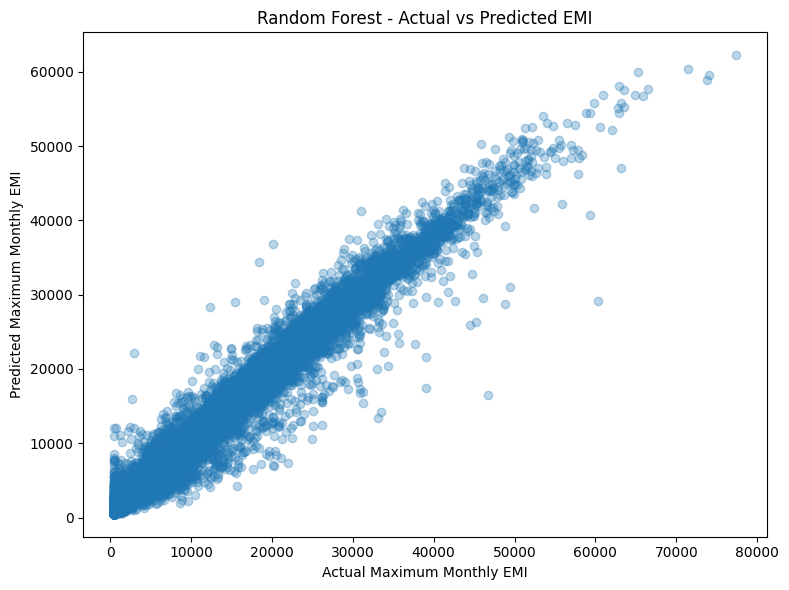

In [25]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf_reg,
    alpha=0.3
)

plt.xlabel("Actual Maximum Monthly EMI")
plt.ylabel("Predicted Maximum Monthly EMI")
plt.title("Random Forest - Actual vs Predicted EMI")

plt.tight_layout()
plt.show()

In [26]:
rf_regressor_path = (
    REGRESSION_MODEL_PATH /
    "random_forest_regressor.pkl"
)

joblib.dump(
    random_forest_regressor,
    rf_regressor_path
)

print("Random Forest Regressor saved!")
print("Path:", rf_regressor_path)

Random Forest Regressor saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\random_forest_regressor.pkl


In [28]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_regressor = GradientBoostingRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

print("Training Gradient Boosting Regressor...")

gradient_boosting_regressor.fit(
    X_train_processed,
    y_train
)



Training Gradient Boosting Regressor...


,loss,'squared_error'
,learning_rate,0.05
,n_estimators,150
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [29]:
y_pred_gb_reg = gradient_boosting_regressor.predict(
    X_test_processed
)

print("Predictions generated successfully!")

print("Number of predictions:", len(y_pred_gb_reg))

print(
    "Minimum predicted EMI:",
    y_pred_gb_reg.min()
)

print(
    "Maximum predicted EMI:",
    y_pred_gb_reg.max()
)

Predictions generated successfully!
Number of predictions: 80960
Minimum predicted EMI: -2947.318768465053
Maximum predicted EMI: 70734.09819258461


In [30]:
gb_reg_mae = mean_absolute_error(
    y_test,
    y_pred_gb_reg
)

gb_reg_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gb_reg
    )
)

gb_reg_r2 = r2_score(
    y_test,
    y_pred_gb_reg
)

print("=" * 60)
print("GRADIENT BOOSTING REGRESSION RESULTS")
print("=" * 60)

print(f"MAE : ₹{gb_reg_mae:,.2f}")
print(f"RMSE: ₹{gb_reg_rmse:,.2f}")
print(f"R²  : {gb_reg_r2:.4f}")

GRADIENT BOOSTING REGRESSION RESULTS
MAE : ₹363.50
RMSE: ₹828.60
R²  : 0.9884


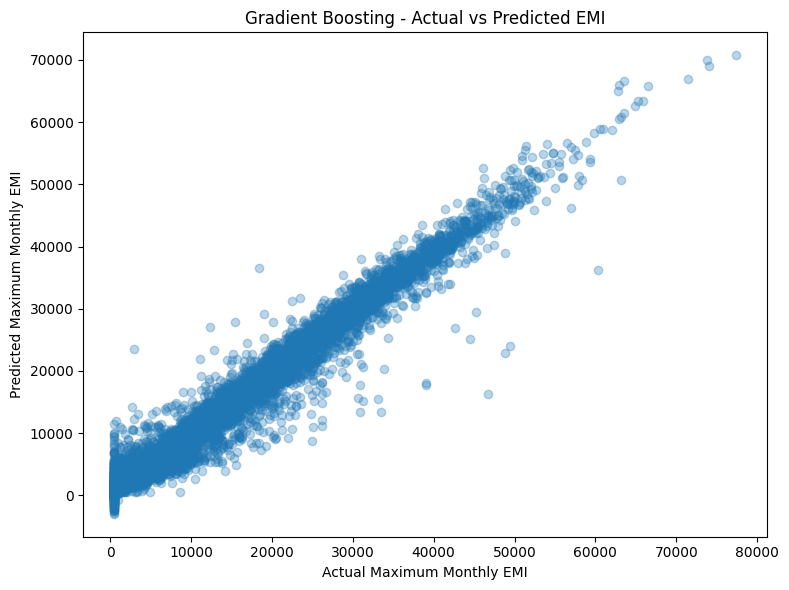

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_gb_reg,
    alpha=0.3
)

plt.xlabel("Actual Maximum Monthly EMI")
plt.ylabel("Predicted Maximum Monthly EMI")
plt.title("Gradient Boosting - Actual vs Predicted EMI")

plt.tight_layout()
plt.show()

In [32]:
gb_regressor_path = (
    REGRESSION_MODEL_PATH /
    "gradient_boosting_regressor.pkl"
)

joblib.dump(
    gradient_boosting_regressor,
    gb_regressor_path
)

print("Gradient Boosting Regressor saved!")
print("Path:", gb_regressor_path)

Gradient Boosting Regressor saved!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\gradient_boosting_regressor.pkl


In [33]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_reg_mae,
        gb_reg_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_reg_rmse,
        gb_reg_rmse
    ],
    "R2": [
        linear_r2,
        rf_reg_r2,
        gb_reg_r2
    ]
})

print("=" * 70)
print("FINAL REGRESSION MODEL COMPARISON")
print("=" * 70)

display(regression_results)

FINAL REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Linear Regression,2915.399070,4050.790450,0.722055
1,Random Forest,470.442864,1021.744155,0.982317
2,Gradient Boosting,363.496971,828.604832,0.988370


In [35]:
final_regression_path = (
    REGRESSION_MODEL_PATH /
    "emi_amount_regressor.pkl"
)

final_regression_model = gradient_boosting_regressor

joblib.dump(
    final_regression_model,
    final_regression_path
)

print("Final regression model saved successfully!")
print("Path:", final_regression_path)

Final regression model saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\emi_amount_regressor.pkl


In [36]:
final_regression_preprocessor_path = (
    REGRESSION_MODEL_PATH /
    "emi_regression_preprocessor.pkl"
)

joblib.dump(
    preprocessor,
    final_regression_preprocessor_path
)

print("Final regression preprocessor saved successfully!")
print(
    "Path:",
    final_regression_preprocessor_path
)

Final regression preprocessor saved successfully!
Path: C:\Users\kalav\OneDrive\Desktop\EMIPredict-AI\models\regression\emi_regression_preprocessor.pkl
